# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы - в markdown-ячейках, формулы в $\LaTeX$; код - в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция - [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)-(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

Переменные - координаты точки $x\in\mathbb R^3$. Минимизируем квадрат расстояния: ближайшая точка от этого не меняется.

$$
f(x)=(x_1-1)^2+(x_2-2)^2+(x_3-3)^2\to\min,\qquad
g(x)=\begin{pmatrix}x_1+x_2+x_3-1\\x_1-x_3\end{pmatrix}=0.
$$
Неравенств нет, поэтому $h$ отсутствует. Это выпуклая QP с ограничениями: цель - сумма квадратов линейных выражений, ограничения - линейные равенства.

Из второго ограничения $x_1-x_3=0$ следует, что $x_1=x_3$. Обозначим их общее значение через $s$: $x_1=x_3=s$.

Подставим в первое ограничение: $s+x_2+s=1$, откуда $x_2=1-2s$. Значит, любая точка прямой имеет вид $x=(s,1-2s,s)$, где $s$ - произвольное действительное число.

После подстановки в целевую функцию получаем $f(s)=6s^2-4s+11$. Приравниваем производную к нулю: $12s-4=0$, поэтому $s=1/3$. Ближайшая точка - $(1/3,1/3,1/3)$.

In [2]:
x0 = np.ones(3) / 3
print("Ближайшая точка:", x0)
print("Расстояние:", np.linalg.norm(x0 - np.array([1, 2, 3])))

Ближайшая точка: [0.33333333 0.33333333 0.33333333]
Расстояние: 3.2145502536643185


**(б)**

$x_j$ - количество продукта $j$, всего $n$ переменных: $x\in\mathbb R^n$.

$$
f(x)=c^\top x\to\min,\qquad
h(x)=\begin{pmatrix}Ax-b\\x\end{pmatrix}\ge0.
$$
Равенств нет, $g$ отсутствует. Первая группа неравенств задаёт минимальное количество веществ, вторая - неотрицательность количества продуктов. Это выпуклая LP с ограничениями: цель и все ограничения линейные.

**(в)**

Расположим центр прямоугольника в начале координат. Его вершины:
$$
(x_1,x_2),\quad (-x_1,x_2),\quad (-x_1,-x_2),\quad (x_1,-x_2),
\qquad x_1,x_2\ge0.
$$
Переменные - координаты вершины в первой четверти: $x=(x_1,x_2)\in\mathbb R^2$. Стороны прямоугольника равны $2x_1$ и $2x_2$, площадь - $4x_1x_2$.

$$
f(x)=-4x_1x_2\to\min,\qquad
h(x)=\begin{pmatrix}1-x_1^2-x_2^2\\x_1\\x_2\end{pmatrix}\ge0.
$$
Равенств нет, $g$ отсутствует. Первое неравенство означает, что вершины лежат в единичном круге. Допускаем и прямоугольники внутри круга, т.к. все равно максимум площади достигается на границе.

Это QCQP с ограничениями. Формулировка невыпуклая: у матрицы вторых производных цели собственные значения $-4$ и $4$, то есть цель не выпуклая.

Из $2x_1x_2\le x_1^2+x_2^2\le1$ получаем максимальную площадь 2. Она достигается при $x_1=x_2=1/\sqrt2$, то есть у квадрата со стороной $\sqrt2$.

**(г)**

Три переменные $x=(x_1,x_2,x_3)\in\mathbb R^3$ задают амплитуду, частоту и фазу синусоиды.

$$
f(x)=\sum_{i=1}^N\bigl(x_1\sin(x_2t_i+x_3)-y_i\bigr)^2\to\min.
$$
Ограничений нет: $g$ и $h$ отсутствуют. Это NLP, в общем случае невыпуклая. Например, для одного измерения $t_1=y_1=0$ при фиксированном $x_1=1$ цель превращается в $\sin^2 x_3$ - невыпуклую функцию.

**(д, бонус)**

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ - логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

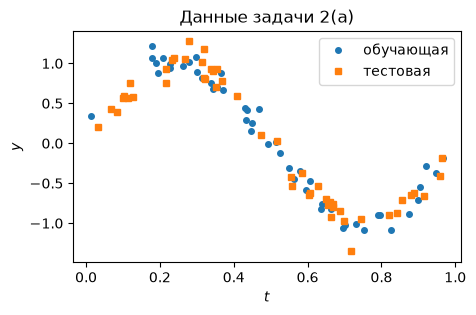

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

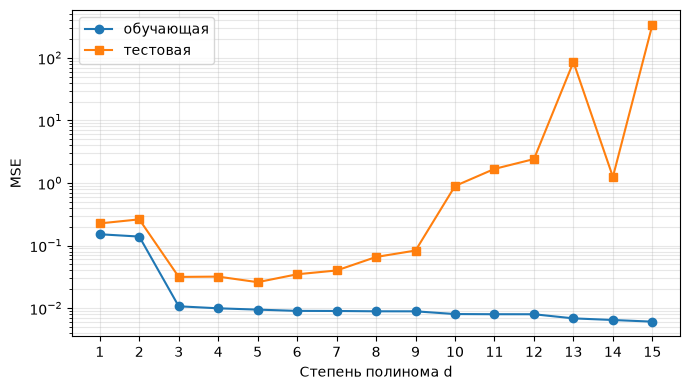

Минимум тестовой MSE: d = 5, MSE = 0.025973


In [4]:
ds = np.arange(1, 16)
mse_tr, mse_te = [], []

for d in ds:
    A_tr = np.vander(t_train, d + 1, increasing=True)
    A_te = np.vander(t_test, d + 1, increasing=True)
    coef = np.linalg.lstsq(A_tr, y_train, rcond=None)[0]
    mse_tr.append(np.mean((A_tr @ coef - y_train) ** 2))
    mse_te.append(np.mean((A_te @ coef - y_test) ** 2))

plt.figure(figsize=(7, 4))
plt.semilogy(ds, mse_tr, "o-", label="обучающая")
plt.semilogy(ds, mse_te, "s-", label="тестовая")
plt.xticks(ds)
plt.xlabel("Степень полинома d")
plt.ylabel("MSE")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best = np.argmin(mse_te)
print(f"Минимум тестовой MSE: d = {ds[best]}, MSE = {mse_te[best]:.6f}")

Обучающая ошибка не возрастает: при увеличении степени можно сохранить прежний полином, положив новый коэффициент равным нулю. Тестовая ошибка сначала падает, когда полином лучше приближает синусоиду, а затем может расти из-за подгонки шума в обучающих данных. На этих данных минимальная тестовая MSE получается при степени 5 и равна примерно 0.026.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
b1 = b.copy()
b1[0] += 1
sols = []

for label, b_cur in [("original: ", b), ("b_0 += 1: ", b1)]:
    res = linprog(c, A_ub=-A, b_ub=-b_cur,
                  bounds=(0, None), method="highs")
    sols.append(res)
    diff = A @ res.x - b_cur
    active_a = np.flatnonzero(np.abs(diff) <= 1e-9) + 1
    active_x = np.flatnonzero(np.abs(res.x) <= 1e-9) + 1
    print(label)
    print("x =", np.round(res.x, 9))
    print(f"Cost = {res.fun:.9f}")
    print("Ax - b =", np.round(diff, 12))
    print("Активные ограничения веществ:", active_a)
    print("Активные x_j >= 0:", active_x)
    print()

print("Изменение x:", np.round(sols[1].x - sols[0].x, 9))
print(f"Изменение стоимости: {sols[1].fun - sols[0].fun:.9f}")

original: 
x = [ 2.  4. -0.  0.]
Cost = 16.000000000
Ax - b = [0. 0. 0.]
Активные ограничения веществ: [1 2 3]
Активные x_j >= 0: [3 4]

b_0 += 1: 
x = [1.88888889 3.55555556 0.         0.66666667]
Cost = 17.111111111
Ax - b = [0. 0. 0.]
Активные ограничения веществ: [1 2 3]
Активные x_j >= 0: [3]

Изменение x: [-0.11111111 -0.44444444  0.          0.66666667]
Изменение стоимости: 1.111111111


В исходной задаче $x^*=(2,4,0,0)$, стоимость - 16. Все три требования по веществам выполнены точно, поэтому соответствующие ограничения активны; также активны $x_3\ge0$ и $x_4\ge0$.

После увеличения первого требования:
$$
\widetilde x^*=\left(\frac{17}{9},\frac{32}{9},0,\frac23\right),\qquad
f(\widetilde x^*)=\frac{154}{9}\approx17.111111.
$$
Первого продукта стало меньше на $1/9$, второго - на $4/9$, четвёртого - больше на $2/3$. Стоимость выросла на $10/9$, то есть примерно на 1.111111.

Все три ограничения по веществам остались активными. Из ограничений неотрицательности теперь активно только $x_3\ge0$: четвёртый продукт появился в решении.